Using device: cpu
Random seed set to: 1234
Epoch   200 | Loss: 8.349e-02 (PDE: 8.348e-02, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch   400 | Loss: 2.830e-02 (PDE: 2.830e-02, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch   600 | Loss: 2.843e-02 (PDE: 2.842e-02, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch   800 | Loss: 4.900e-02 (PDE: 4.899e-02, BC(mon.): 0.000e+00, lr=1.0e-03)
Epoch  1000 | Loss: 1.882e-02 (PDE: 1.882e-02, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  1200 | Loss: 1.212e-01 (PDE: 1.212e-01, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  1400 | Loss: 6.843e-02 (PDE: 6.842e-02, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  1600 | Loss: 4.818e-02 (PDE: 4.817e-02, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  1800 | Loss: 5.720e-02 (PDE: 5.719e-02, BC(mon.): 0.000e+00, lr=5.0e-04)
Epoch  2000 | Loss: 5.148e-02 (PDE: 5.147e-02, BC(mon.): 0.000e+00, lr=2.5e-04)

Best training loss = 1.609e-02

Model saved to: meta_poisson_model.pt
Loaded model from: meta_poisson_model.pt

=== Test case 1/4: center_in_range ===
  (x0

/tmp/ipykernel_66225/1395071734.py:586: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(MODEL_PATH, map_location=device)


  Relative L2 error = 2.008e-02

=== Test case 2/4: off_center_in_range ===
  (x0, y0, nu) = (0.450, 0.550, 0.090)
  Relative L2 error = 1.195e-02

=== Test case 3/4: shifted_out_of_range ===
  (x0, y0, nu) = (0.300, 0.300, 0.060)
  Relative L2 error = 3.569e-01

=== Test case 4/4: narrow_out_of_range ===
  (x0, y0, nu) = (0.500, 0.500, 0.030)
  Relative L2 error = 3.869e-02

[Saved standardized bundle] outputs_kapi/kapi_bundle.npz
Bundle contains keys: x, y, params, case_names, u_exact, u_pred, abs_error (+ optional extras)

Saved solution comparison figure to: figures/meta_poisson_results.png


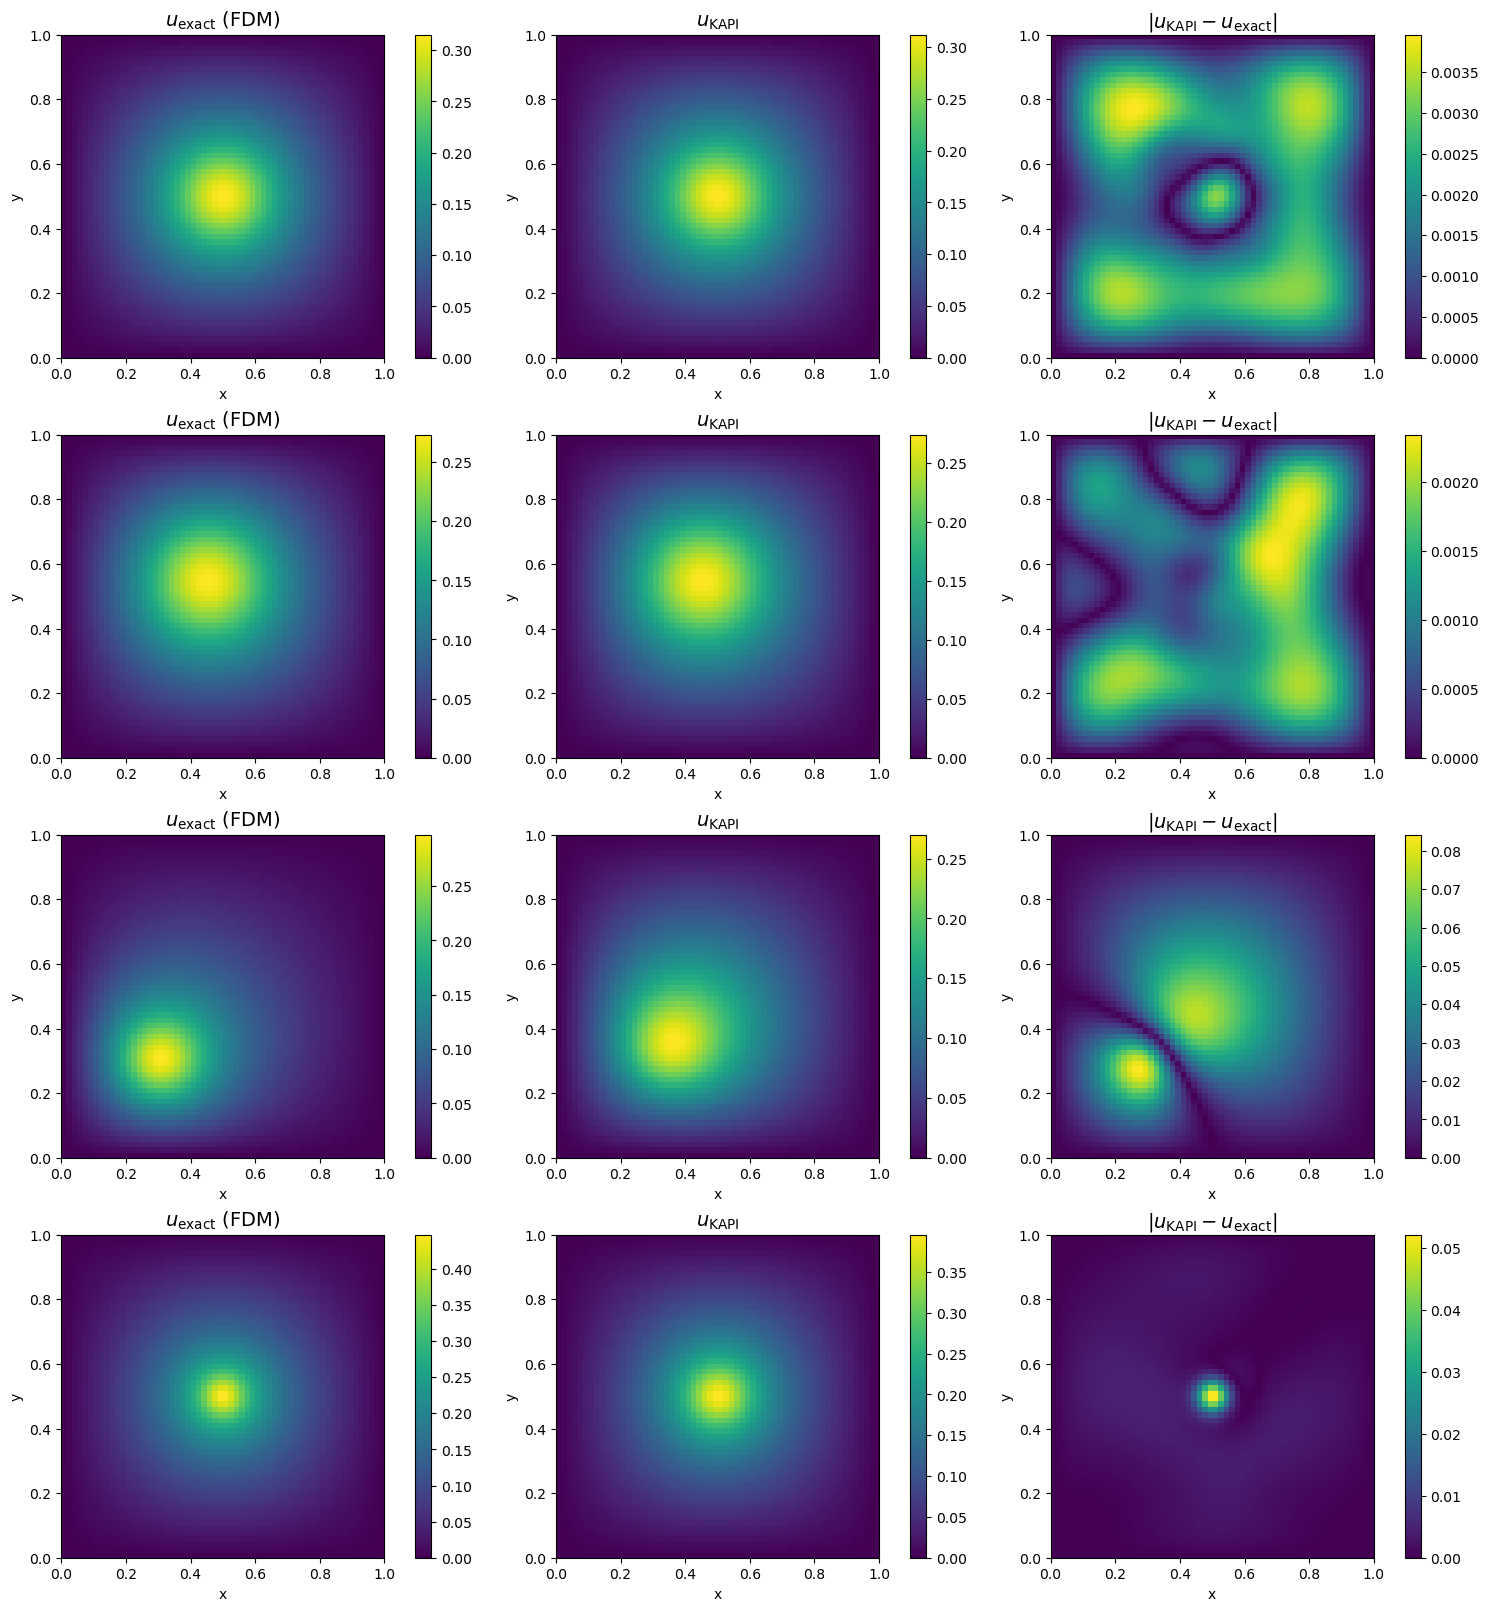


Summary of relative L2 errors:
  center_in_range          : 2.008e-02
  off_center_in_range      : 1.195e-02
  shifted_out_of_range     : 3.569e-01
  narrow_out_of_range      : 3.869e-02


In [1]:
"""
2D Poisson with Gaussian source:
    -Δu = f(x,y; x0, y0, nu)  on [0,1]^2,  u = 0 on boundary.
"""

import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Standardized directory for saving fields for later comparison plots
DATA_DIR = "outputs_kapi"
os.makedirs(DATA_DIR, exist_ok=True)

MODEL_PATH = "meta_poisson_model.pt"

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print("Random seed set to:", SEED)

# ------------------------------------------------------------
# 2D Gaussian source term for Poisson
# f(x,y) = (1/(2πν^2)) exp(-r^2/(2ν^2))
# ------------------------------------------------------------
def gaussian_source(x, y, x0, y0, nu):
    """
    x, y: (N,) tensors
    x0, y0, nu: scalar tensors (or floats)
    returns f(x,y) shape (N,)
    """
    r2 = (x - x0) ** 2 + (y - y0) ** 2
    return (1.0 / (2.0 * torch.pi * nu ** 2)) * torch.exp(-r2 / (2.0 * nu ** 2))


# ------------------------------------------------------------
# KAPI-RBF PINN model (meta-conditioned on PDE parameters)
# ------------------------------------------------------------
class KAPIRBF_PINN(nn.Module):
    def __init__(self, M=128, hidden_meta=64):
        super().__init__()
        self.M = M

        # Meta-network: p_norm -> [g_logits, mu_x_raw, mu_y_raw, log_sigma_raw]
        self.meta = nn.Sequential(
            nn.Linear(3, hidden_meta),
            nn.Tanh(),
            nn.Linear(hidden_meta, hidden_meta),
            nn.Tanh(),
            nn.Linear(hidden_meta, 4 * M),
        )

        # Global coefficients c_j (shared across all PDE params), small random init
        self.c = nn.Parameter(1e-2 * torch.randn(M))

    def _forward_raw(self, p, xy):
        """
        Raw RBF expansion (no BC factor).
        p:  (1,3) tensor, PDE parameter [x0, y0, nu]
        xy: (N,2) spatial points in [0,1]^2
        Returns:
            u_raw: (N,)
            aux:   (g, mu_x, mu_y, sigma)
        """
        assert p.shape[0] == 1, "This implementation assumes a single p per call."

        # Normalize p = (x0, y0, nu) with fixed mean/std
        p_mean = p.new_tensor([0.5, 0.5, 0.075])
        p_std  = p.new_tensor([0.1, 0.1, 0.025])
        p_norm = (p - p_mean) / p_std

        # meta-mapping
        meta_out = self.meta(p_norm)  # (1, 4*M)
        meta_out = meta_out.view(1, 4, self.M)

        g_logits   = meta_out[:, 0, :]  # (1, M)
        mu_raw_x   = meta_out[:, 1, :]  # (1, M)
        mu_raw_y   = meta_out[:, 2, :]  # (1, M)
        log_sigraw = meta_out[:, 3, :]  # (1, M)

        # Gates in (0,1)
        g = torch.sigmoid(g_logits).view(self.M)  # (M,)

        # Centers in (0,1)
        mu_x = torch.sigmoid(mu_raw_x).view(self.M)
        mu_y = torch.sigmoid(mu_raw_y).view(self.M)

        # Widths > 0
        sigma = torch.nn.functional.softplus(log_sigraw).view(self.M) + 5e-4

        # Build RBF features Phi(x,y) -> (N,M)
        x = xy[:, 0:1]  # (N,1)
        y = xy[:, 1:2]  # (N,1)

        x_diff = x - mu_x.view(1, self.M)
        y_diff = y - mu_y.view(1, self.M)
        r2 = (x_diff ** 2 + y_diff ** 2) / (sigma.view(1, self.M) ** 2)
        Phi = torch.exp(-r2)  # (N,M)

        coeff = g * self.c  # (M,)
        u_raw = Phi @ coeff  # (N,)

        return u_raw, (g, mu_x, mu_y, sigma)

    def forward(self, p, xy):
        """
        Full forward with BC-satisfying trial ansatz:
            u(x,y;p) = x(1-x)y(1-y) * u_raw(x,y;p)
        """
        u_raw, aux = self._forward_raw(p, xy)
        x, y = xy[:, 0:1], xy[:, 1:2]
        bc_factor = x * (1.0 - x) * y * (1.0 - y)  # (N,1)
        u = u_raw * bc_factor.view(-1)  # (N,)
        return u, aux


# ------------------------------------------------------------
# p-dependent collocation and boundary points on [0,1]^2
# ------------------------------------------------------------
def sample_collocation_points_p_dependent(
    N_int,
    N_bc,
    p,
    alpha=None,
    sigma_factor=3.0,
    device=device
):
    """
    N_int : number of interior collocation points
    N_bc  : number of boundary collocation points
    p     : (1,3) tensor = [x0, y0, nu] on 'device'
    """
    x0, y0, nu = p[0]  # each is scalar tensor

    # Choose alpha based on nu: more localized sampling for smaller nu
    if alpha is None:
        alpha = 0.9 if nu.item() < 0.06 else 0.7

    # Interior points
    N_loc = int(alpha * N_int)
    N_uni = N_int - N_loc

    if N_loc > 0:
        loc_x = x0 + sigma_factor * nu * torch.randn(N_loc, 1, device=device)
        loc_y = y0 + sigma_factor * nu * torch.randn(N_loc, 1, device=device)
        loc_x = loc_x.clamp(0.0, 1.0)
        loc_y = loc_y.clamp(0.0, 1.0)
        xy_loc = torch.cat([loc_x, loc_y], dim=1)
    else:
        xy_loc = torch.empty(0, 2, device=device)

    if N_uni > 0:
        uni_x = torch.rand(N_uni, 1, device=device)
        uni_y = torch.rand(N_uni, 1, device=device)
        xy_uni = torch.cat([uni_x, uni_y], dim=1)
    else:
        xy_uni = torch.empty(0, 2, device=device)

    xy_int = torch.cat([xy_loc, xy_uni], dim=0)

    # Boundary points (monitoring only; hard BC is in ansatz)
    if N_bc > 0:
        N_side = N_bc // 4
        t = torch.rand(N_side, 1, device=device)

        xb = torch.cat([
            torch.zeros(N_side, 1, device=device),
            torch.ones(N_side, 1, device=device),
            t,
            t
        ], dim=0)

        yb = torch.cat([
            t,
            t,
            torch.zeros(N_side, 1, device=device),
            torch.ones(N_side, 1, device=device)
        ], dim=0)

        xy_bc = torch.cat([xb, yb], dim=1)
    else:
        xy_bc = torch.empty(0, 2, device=device)

    return xy_int, xy_bc


# ------------------------------------------------------------
# Poisson residual: -Δu - f(x,y;p)
# ------------------------------------------------------------
def poisson_residual(model, p, xy_int):
    xy_int.requires_grad_(True)
    u, _ = model(p, xy_int)

    grads = torch.autograd.grad(
        u, xy_int,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_x = grads[:, 0]
    u_y = grads[:, 1]

    grads2_x = torch.autograd.grad(
        u_x, xy_int,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True
    )[0]

    grads2_y = torch.autograd.grad(
        u_y, xy_int,
        grad_outputs=torch.ones_like(u_y),
        create_graph=True
    )[0]

    u_xx = grads2_x[:, 0]
    u_yy = grads2_y[:, 1]
    laplace_u = u_xx + u_yy

    x = xy_int[:, 0]
    y = xy_int[:, 1]
    x0, y0, nu = p[0, 0], p[0, 1], p[0, 2]
    f_val = gaussian_source(x, y, x0, y0, nu)

    return -laplace_u - f_val


# ------------------------------------------------------------
# Sample PDE parameters p = (x0, y0, nu)
# ------------------------------------------------------------
x0_min, x0_max = 0.4, 0.6
y0_min, y0_max = 0.4, 0.6
nu_min, nu_max = 0.05, 0.1

def sample_pde_param(nu_min_curr=None, nu_max_curr=None):
    if nu_min_curr is None:
        nu_min_curr = nu_min
    if nu_max_curr is None:
        nu_max_curr = nu_max

    x0 = x0_min + (x0_max - x0_min) * torch.rand(1)
    y0 = y0_min + (y0_max - y0_min) * torch.rand(1)

    # log-uniform in nu
    u = torch.rand(1)
    nu_min_t = torch.tensor(nu_min_curr)
    nu_max_t = torch.tensor(nu_max_curr)
    nu = 10.0 ** (torch.log10(nu_min_t) +
                  (torch.log10(nu_max_t) - torch.log10(nu_min_t)) * u)

    p = torch.stack([x0, y0, nu], dim=-1)  # (1,3)
    return p.to(device)


# ------------------------------------------------------------
# Meta-training loop
# ------------------------------------------------------------
def train_meta_poisson(
    n_int=2048,
    n_bc=256,
    epochs=2000,
    lr=1e-3,
    M=128,
    tasks_per_batch=4
):
    model = KAPIRBF_PINN(M=M, hidden_meta=64).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = StepLR(optimizer, step_size=1000, gamma=0.5)

    best_loss = float("inf")
    best_state = None

    history = {"epoch": [], "total_loss": [], "pde_loss": [], "bc_loss": [], "lr": []}

    for ep in range(1, epochs + 1):
        optimizer.zero_grad()

        total_loss = 0.0
        total_pde  = 0.0
        total_bc   = 0.0

        # ν-curriculum
        if ep <= epochs // 2:
            nu_min_curr, nu_max_curr = 0.08, nu_max
        else:
            nu_min_curr, nu_max_curr = nu_min, nu_max

        for _ in range(tasks_per_batch):
            p = sample_pde_param(nu_min_curr, nu_max_curr)

            xy_int, xy_bc = sample_collocation_points_p_dependent(
                n_int, n_bc, p, alpha=None, sigma_factor=3.0, device=device
            )

            # PDE loss
            res_int = poisson_residual(model, p, xy_int)
            loss_pde = torch.mean(res_int ** 2)

            # BC monitoring loss (u should already satisfy BC)
            if xy_bc.shape[0] > 0:
                u_bc, (g_bc, _, _, _) = model(p, xy_bc)
                loss_bc = torch.mean(u_bc ** 2)
            else:
                dummy_xy = torch.zeros(1, 2, device=device)
                _, (g_bc, _, _, _) = model(p, dummy_xy)
                loss_bc = torch.tensor(0.0, device=device)

            # Optional sparsity penalty
            loss_sparse = 1e-5 * torch.mean(torch.abs(g_bc))

            loss_task = loss_pde + loss_sparse
            total_loss += loss_task
            total_pde  += loss_pde
            total_bc   += loss_bc

        total_loss /= tasks_per_batch
        total_pde  /= tasks_per_batch
        total_bc   /= tasks_per_batch

        total_loss.backward()
        optimizer.step()
        scheduler.step()

        current_lr = scheduler.get_last_lr()[0]
        history["epoch"].append(ep)
        history["total_loss"].append(total_loss.item())
        history["pde_loss"].append(total_pde.item())
        history["bc_loss"].append(total_bc.item())
        history["lr"].append(current_lr)

        if total_loss.item() < best_loss:
            best_loss = total_loss.item()
            best_state = model.state_dict()

        if ep % 200 == 0:
            print(
                f"Epoch {ep:5d} | Loss: {total_loss.item():.3e} "
                f"(PDE: {total_pde.item():.3e}, BC(mon.): {total_bc.item():.3e}, lr={current_lr:.1e})"
            )

    print(f"\nBest training loss = {best_loss:.3e}")
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


# ------------------------------------------------------------
# FDM "exact" solver for a fixed Poisson instance
# ------------------------------------------------------------
def poisson_exact_fdm(N=60, x0=0.5, y0=0.5, nu=0.05):
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    dx = x[1] - x[0]
    X, Y = np.meshgrid(x, y, indexing="ij")

    r2 = (X - x0) ** 2 + (Y - y0) ** 2
    f = (1.0 / (2.0 * np.pi * nu ** 2)) * np.exp(-r2 / (2.0 * nu ** 2))

    Nint = N - 2
    f_inner = f[1:-1, 1:-1].reshape(-1)

    e = np.ones(Nint)
    D2 = (np.diag(-2 * e) + np.diag(e[:-1], 1) + np.diag(e[:-1], -1)) / dx ** 2
    I = np.eye(Nint)

    L = np.kron(I, D2) + np.kron(D2, I)
    rhs = -f_inner

    u_inner = np.linalg.solve(L, rhs)
    u = np.zeros((N, N))
    u[1:-1, 1:-1] = u_inner.reshape(Nint, Nint)
    return x, y, u


# ------------------------------------------------------------
# Test cases
# ------------------------------------------------------------
test_cases = [
    ("center_in_range",      0.50, 0.50, 0.07),
    ("off_center_in_range",  0.45, 0.55, 0.09),
    ("shifted_out_of_range", 0.30, 0.30, 0.06),
    ("narrow_out_of_range",  0.50, 0.50, 0.03),
]


# ------------------------------------------------------------
# Evaluate, plot, and SAVE standardized outputs
# ------------------------------------------------------------
def evaluate_and_plot_solutions(model, N=60, save_data=True, out_dir=DATA_DIR):
    """
    Produces:
    - per-case plots (Exact / Pred / |Error|)
    - per-case NPZ files (optional, with extra debug fields)
    - ONE standardized bundle NPZ for unified publication plots across methods:
        kapi_bundle.npz containing:
            x, y, params, case_names, u_exact, u_pred, abs_error
    """
    num_tests = len(test_cases)
    fig, axs = plt.subplots(num_tests, 3, figsize=(15, 4 * num_tests), constrained_layout=True)
    if num_tests == 1:
        axs = np.array([axs])

    model.eval()
    rel_errors = []

    # -----------------------------
    # Accumulators for standardized bundle
    # -----------------------------
    if save_data:
        os.makedirs(out_dir, exist_ok=True)

        all_case_names = []
        all_params     = []
        all_u_exact    = []
        all_u_pred     = []
        all_abs_err    = []

        grid_x = None
        grid_y = None

    for i, (case_name, x0_test, y0_test, nu_test) in enumerate(test_cases):
        print(f"\n=== Test case {i+1}/{num_tests}: {case_name} ===")
        print(f"  (x0, y0, nu) = ({x0_test:.3f}, {y0_test:.3f}, {nu_test:.3f})")

        # Exact solution from FDM
        xg, yg, u_exact = poisson_exact_fdm(N=N, x0=x0_test, y0=y0_test, nu=nu_test)

        # Build grid for model evaluation
        Xg, Yg = np.meshgrid(xg, yg, indexing="ij")
        xy_grid = np.stack([Xg.reshape(-1), Yg.reshape(-1)], axis=1)
        xy_grid_t = torch.tensor(xy_grid, dtype=torch.float32, device=device)

        p_test = torch.tensor([[x0_test, y0_test, nu_test]], dtype=torch.float32, device=device)

        # Predict with KAPI model
        with torch.no_grad():
            u_pred_flat, _ = model(p_test, xy_grid_t)
        u_pred = u_pred_flat.cpu().numpy().reshape(N, N)

        # Errors
        error = (u_pred - u_exact)
        abs_error = np.abs(error)

        # Relative L2 (diagnostic)
        rel_L2 = np.linalg.norm(error.ravel()) / (np.linalg.norm(u_exact.ravel()) + 1e-14)
        rel_errors.append((case_name, rel_L2))
        print(f"  Relative L2 error = {rel_L2:.3e}")

        # -----------------------------
        # Save per-case NPZ (debug-friendly; can include extra fields)
        # -----------------------------
        if save_data:
            case_path = os.path.join(out_dir, f"kapi_case_{i:02d}_{case_name}.npz")
            np.savez_compressed(
                case_path,
                case_name=case_name,
                params=np.array([x0_test, y0_test, nu_test], dtype=np.float32),
                x=np.asarray(xg, dtype=np.float32),
                y=np.asarray(yg, dtype=np.float32),
                u_exact=u_exact.astype(np.float32),
                u_pred=u_pred.astype(np.float32),
                abs_error=abs_error.astype(np.float32),

                # extra fields are OK (won't break standardized plotting)
                error=error.astype(np.float32),
                rel_L2=np.float32(rel_L2),
                method=np.asarray("KAPI"),
            )

            # Accumulate for standardized bundle
            all_case_names.append(case_name)
            all_params.append([x0_test, y0_test, nu_test])
            all_u_exact.append(u_exact.astype(np.float32))
            all_u_pred.append(u_pred.astype(np.float32))
            all_abs_err.append(abs_error.astype(np.float32))

            if grid_x is None:
                grid_x = np.asarray(xg, dtype=np.float32)
                grid_y = np.asarray(yg, dtype=np.float32)

        # -----------------------------
        # Plot: Exact / Pred / Abs Error
        # -----------------------------
        ax0, ax1, ax2 = axs[i, 0], axs[i, 1], axs[i, 2]

        im0 = ax0.imshow(u_exact.T, origin="lower", extent=[0, 1, 0, 1])
        ax0.set_title(r"$u_{\mathrm{exact}}$ (FDM)", fontsize=14)
        ax0.set_xlabel("x"); ax0.set_ylabel("y")
        plt.colorbar(im0, ax=ax0)

        im1 = ax1.imshow(u_pred.T, origin="lower", extent=[0, 1, 0, 1])
        ax1.set_title(r"$u_{\mathrm{KAPI}}$", fontsize=14)
        ax1.set_xlabel("x"); ax1.set_ylabel("y")
        plt.colorbar(im1, ax=ax1)

        im2 = ax2.imshow(abs_error.T, origin="lower", extent=[0, 1, 0, 1])
        ax2.set_title(r"$|u_{\mathrm{KAPI}} - u_{\mathrm{exact}}|$", fontsize=14)
        ax2.set_xlabel("x"); ax2.set_ylabel("y")
        plt.colorbar(im2, ax=ax2)

    # -----------------------------
    # Save ONE standardized bundle for unified publication plotting
    # -----------------------------
    if save_data:
        bundle_path = os.path.join(out_dir, "kapi_bundle.npz")

        np.savez_compressed(
            bundle_path,
            # REQUIRED STANDARD KEYS (for later unified plotting)
            x=grid_x,                              # (N,)
            y=grid_y,                              # (N,)
            params=np.asarray(all_params, dtype=np.float32),     # (n_cases, 3)
            case_names=np.asarray(all_case_names),               # (n_cases,)
            u_exact=np.stack(all_u_exact, axis=0),               # (n_cases, N, N)
            u_pred=np.stack(all_u_pred, axis=0),                 # (n_cases, N, N)
            abs_error=np.stack(all_abs_err, axis=0),             # (n_cases, N, N)

            # OPTIONAL EXTRAS are allowed
            method=np.asarray("KAPI"),
        )

        print(f"\n[Saved standardized bundle] {bundle_path}")
        print("Bundle contains keys: x, y, params, case_names, u_exact, u_pred, abs_error (+ optional extras)")

    # Save the local 3-column figure (your existing one)
    results_path = os.path.join(FIG_DIR, "meta_poisson_results.png")
    plt.savefig(results_path, dpi=300, bbox_inches="tight")
    print(f"\nSaved solution comparison figure to: {results_path}")
    plt.show()

    print("\nSummary of relative L2 errors:")
    for nm, e in rel_errors:
        print(f"  {nm:25s}: {e:.3e}")


# ------------------------------------------------------------
# Train + save + reload + evaluate (as in your original workflow)
# ------------------------------------------------------------
if __name__ == "__main__":
    n_int = 2048
    n_bc = 256
    epochs = 2000
    lr = 1e-3
    M = 128
    tasks_per_batch = 4

    model, history = train_meta_poisson(
        n_int=n_int,
        n_bc=n_bc,
        epochs=epochs,
        lr=lr,
        M=M,
        tasks_per_batch=tasks_per_batch
    )

    # Save trained model weights
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"\nModel saved to: {MODEL_PATH}")

    # Reload model (optional but matches your script flow)
    loaded_model = KAPIRBF_PINN(M=M, hidden_meta=64).to(device)
    state_dict = torch.load(MODEL_PATH, map_location=device)
    loaded_model.load_state_dict(state_dict)
    loaded_model.eval()
    print("Loaded model from:", MODEL_PATH)

    # Evaluate and export standardized outputs
    evaluate_and_plot_solutions(loaded_model, N=60, save_data=True, out_dir=DATA_DIR)
